In [308]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
from prodigyopt import Prodigy # proddigy optimizer from https://github.com/konstmish/prodigy?tab=readme-ov-file

import tqdm
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use("Agg")
# matplolib inline 
%matplotlib inline
# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy
import time

# remove all warnings
import warnings
warnings.filterwarnings("ignore")
from utils.multi_loss import ema_losses

import os
import dotenv
dotenv.load_dotenv()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


True

In [309]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()

In [310]:
epochs = 1000
representiation_dim = 64
EXPERIMENT_NAME=r'0.1%basis-set'

In [311]:

CONFIG = {
    # Model configuration
    'representation_dim': representiation_dim, # Dimension of the representation
    'dim_mults':(1, 2, 4, 8), # Dimension multipliers for hidden layers of the model # (1, 4, 8)
    'attention':False, 
    
    # Encoder configuration
    'embeder_num_of_hidden_layers' : 1,
    'encoder_conditional_dim': representiation_dim,
    'encoder_type': 'basis_set', # 'basis_set' or 'vae'

    # encoding types
    'path_type': 'path', # 'path' or 'offset_path'
    'condition_type': 'world_img', # world_distance_field_img, world_img, world_indx

    # Hyperparameters for training
    'batch_size': 8,
    'num_epochs': epochs,
    'ema': EMA(beta=0.99), # Exponential moving average for the model weights
        ## Optimizer configuration
        'optimizer': Prodigy,
        'optimizer_kwargs': {
            'lr': 1., # ! ONLY FOR PRODIGY OPTIMIZER
            'weight_decay': 0.01, 
            'safeguard_warmup':True,
            'use_bias_correction':True,
            'betas': (0.9, 0.99),
            },
        # Scheduler configuration
        'scheduler': torch.optim.lr_scheduler.CosineAnnealingLR,
        'scheduler_kwargs': {
            # 'gamma': 0.999,
            'T_max': 10, # Total number of iterations
        },

        'multi_loss_warm_up_steps': 2000,
        'loss_weights':{
            'MSE': 0.5, # best for overfitting 1 sample is 0.004
            'ObstacleFreePathLoss': 0.4, # bround truth avg prefromance is 0.00008 with std 0.27
            'GraphBasedConsistencyLoss': 0.1, # ground truth avg prefromance is 0.00031 with std = 1.09
        },

    # Hyperparameters for diffusion process
    'noise_steps': 1000,
    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    'cfg_scale': 3,


    # Dataset specific configuration
    'n_paths_per_world': 1000,
    'n_worlds': 1,
    'n_waypoints': 64, # due to the archtechture has to be a number that is a power of 2 
    'single_world_dataset': True,
    'entire_dataset': False,
    'fraction_of_data': 0.001,

    # logging 
    'visualize_every_n_epochs': 1,
    'stats_every_n_steps': 100,
}

In [312]:
from dataset import RobotPathDataset

In [313]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
device

cuda:0


device(type='cuda', index=0)

In [314]:
if CONFIG['single_world_dataset']:
    file = os.getenv('ONE_WORLD_DATASET_PATH')
else:
    file = os.getenv('FULL_DATASET_PATH')
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'], single_world_dataset=CONFIG['single_world_dataset'], entire_dataset=CONFIG['entire_dataset'], fraction_of_data=CONFIG['fraction_of_data'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

data shape: torch.Size([1000, 64, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:1, samples: 1000
 sample shape torch.Size([64, 2]) with 1000 samples


# Archtechture

### encoder

In [315]:
from model import WorldIndexEmbeder, FlattenEmbeder, VAEXperiment, BPS_Encoder

In [316]:
def reset_weights(model):
    for layer in model.children():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()



In [317]:
# Import pretrained vae model
model_experiment = VAEXperiment.load_from_checkpoint(r'pretrained_models/64-encoder.ckpt')
# model_experiment.freeze()
reset_weights(model_experiment)
vae_model = model_experiment.model
vae_model.to(device)
vae_model.encoder.to(device)

Sequential(
  (0): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (1): Sequential(
    (0): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(

In [318]:
from model import Encoder
class wrapper_encoder(Encoder):
    def __init__(self, vae_model):
        super(wrapper_encoder, self).__init__()
        self.vae_model = vae_model
    def forward(self, x):
        results = self.vae_model.encode(x)
        mu, log_var = results
        z = self.vae_model.reparameterize(mu, log_var)
        return z

    def decode(self, z):
        return self.vae_model.decode(z)

In [319]:
embedding_dim = CONFIG['encoder_conditional_dim']
# Define the model
sample_input = sample['world_distance_field_img']

In [320]:
if CONFIG['encoder_type'] == 'vae':
    encoder = wrapper_encoder(vae_model)
elif CONFIG['encoder_type'] == 'basis_set':
    encoder = BPS_Encoder(n_bps_points=CONFIG['encoder_conditional_dim'], n_dims=2, minv=0, maxv=64, device=device)

### Model and diffusion

In [321]:
from model import Diffusion, TemporalUnet

In [322]:
# Create the UNet
transition_dim = sample['path'].shape[-1] # transition_dim is the dimension the model should predict. not the timesteps
print(transition_dim)
model = TemporalUnet(horizon=CONFIG['noise_steps'], transition_dim=transition_dim, dim=CONFIG['representation_dim'], dim_mults=CONFIG['dim_mults'],encoder=encoder, attention=CONFIG['attention'],device=device)

2
[ models/temporal ] Channel dimensions: [(2, 64), (64, 128), (128, 256), (256, 512)]
[ models/temporal ] Embedding dimensions: env encoding 32, start_pos encoding 8, end_pos encoding 8, time encoding 16
[(2, 64), (64, 128), (128, 256), (256, 512)]


In [323]:
model.to(device);
model.device

device(type='cuda', index=0)

In [324]:
# create the diffusion model
diffusion = Diffusion(input_shape=sample['path'].shape, noise_steps=CONFIG['noise_steps'], device=device)

In [325]:
# write training loop 
import torch.optim as optim
import torch.nn as nn
from utils.visualize.vae import plot_vae_reconstruciton
from utils.visualize.diffusion import plot_diffusions, plot_noise_and_predicted_noise

In [326]:
from LoggingManager import LoggingManager
logging_manager = LoggingManager(experiement_name=EXPERIMENT_NAME)
logging_manager.log_config(CONFIG);

INFO:LoggingManager:Configuration:
INFO:LoggingManager:representation_dim: 64
INFO:LoggingManager:dim_mults: (1, 2, 4, 8)
INFO:LoggingManager:attention: False
INFO:LoggingManager:embeder_num_of_hidden_layers: 1
INFO:LoggingManager:encoder_conditional_dim: 64
INFO:LoggingManager:encoder_type: basis_set
INFO:LoggingManager:path_type: path
INFO:LoggingManager:condition_type: world_img
INFO:LoggingManager:batch_size: 8
INFO:LoggingManager:num_epochs: 1000
INFO:LoggingManager:ema: <model.models.EMA object at 0x0000019A68157F70>
INFO:LoggingManager:optimizer: <class 'prodigyopt.prodigy.Prodigy'>
INFO:LoggingManager:optimizer_kwargs: {'lr': 1.0, 'weight_decay': 0.01, 'safeguard_warmup': True, 'use_bias_correction': True, 'betas': (0.9, 0.99)}
INFO:LoggingManager:scheduler: <class 'torch.optim.lr_scheduler.CosineAnnealingLR'>
INFO:LoggingManager:scheduler_kwargs: {'T_max': 10}
INFO:LoggingManager:multi_loss_warm_up_steps: 2000
INFO:LoggingManager:loss_weights: {'MSE': 0.5, 'ObstacleFreePathLos

Logging to logs\0.1%basis-set/16h-18m-20-07-2024/logs.log


In [327]:

START_FROM_CHECKPOINT = True
Checkpoint_file = os.getenv('PRETRAINED_MODEL')

optimizer = CONFIG['optimizer'](model.parameters(), **CONFIG['optimizer_kwargs'])
scheduler = CONFIG['scheduler'](optimizer, **CONFIG['scheduler_kwargs'])
ema = CONFIG['ema']
ema_model = copy.deepcopy(model).eval().requires_grad_(False)
epoch = 0
# Restart from checkpoint 
if START_FROM_CHECKPOINT:
    model, optimizer, scheduler, epoch, loss = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=Checkpoint_file)
    ema.step_ema(ema_model,model)
    logging_manager.log_message(f'Restarting from epoch {epoch} with loss {loss}')
    print(f'Restarting from epoch {epoch} with loss {loss}')


Using decoupled weight decay


INFO:LoggingManager:Checkpoint loaded from pretrained_models\model-epoch_40-loss_0.033-time_18h-05m-13-07-2024
INFO:LoggingManager:Restarting from epoch 40 with loss 0.033490926027297974


Restarting from epoch 40 with loss 0.033490926027297974


In [328]:
# create the diffusion model
diffusion = Diffusion(input_shape=sample['path'].shape, noise_steps=264, sigma=0.5,device=device)

In [329]:

# diffusion variables
n = 3
batch = next(iter(torch.utils.data.DataLoader(dataset, batch_size=n, shuffle=True)))

x = batch['path']
x = x.to(device)
cond = batch['world_img']
world_imgs = batch['world_img']
cond = cond.to(device)
paths = x
true_paths = batch['og_path']
x.shape, cond.shape

(torch.Size([3, 64, 2]), torch.Size([3, 64, 64]))

In [330]:
samples , intermediates = diffusion.sample_from_paths(model, n=n, paths=paths, cond=cond, normalizer=CONFIG['normalizer'])

263it [00:08, 30.86it/s]


In [331]:
def info(tensor):
    return f'mean {tensor.mean()} std {tensor.std()}, min {tensor.min()} max {tensor.max()}'
info(samples), info(intermediates[0])

('mean 0.10754835605621338 std 0.4872027337551117, min -0.966197669506073 max 1.0470067262649536',
 'mean 0.002239598659798503 std 0.46117061376571655, min -1.3979063034057617 max 1.3443818092346191')

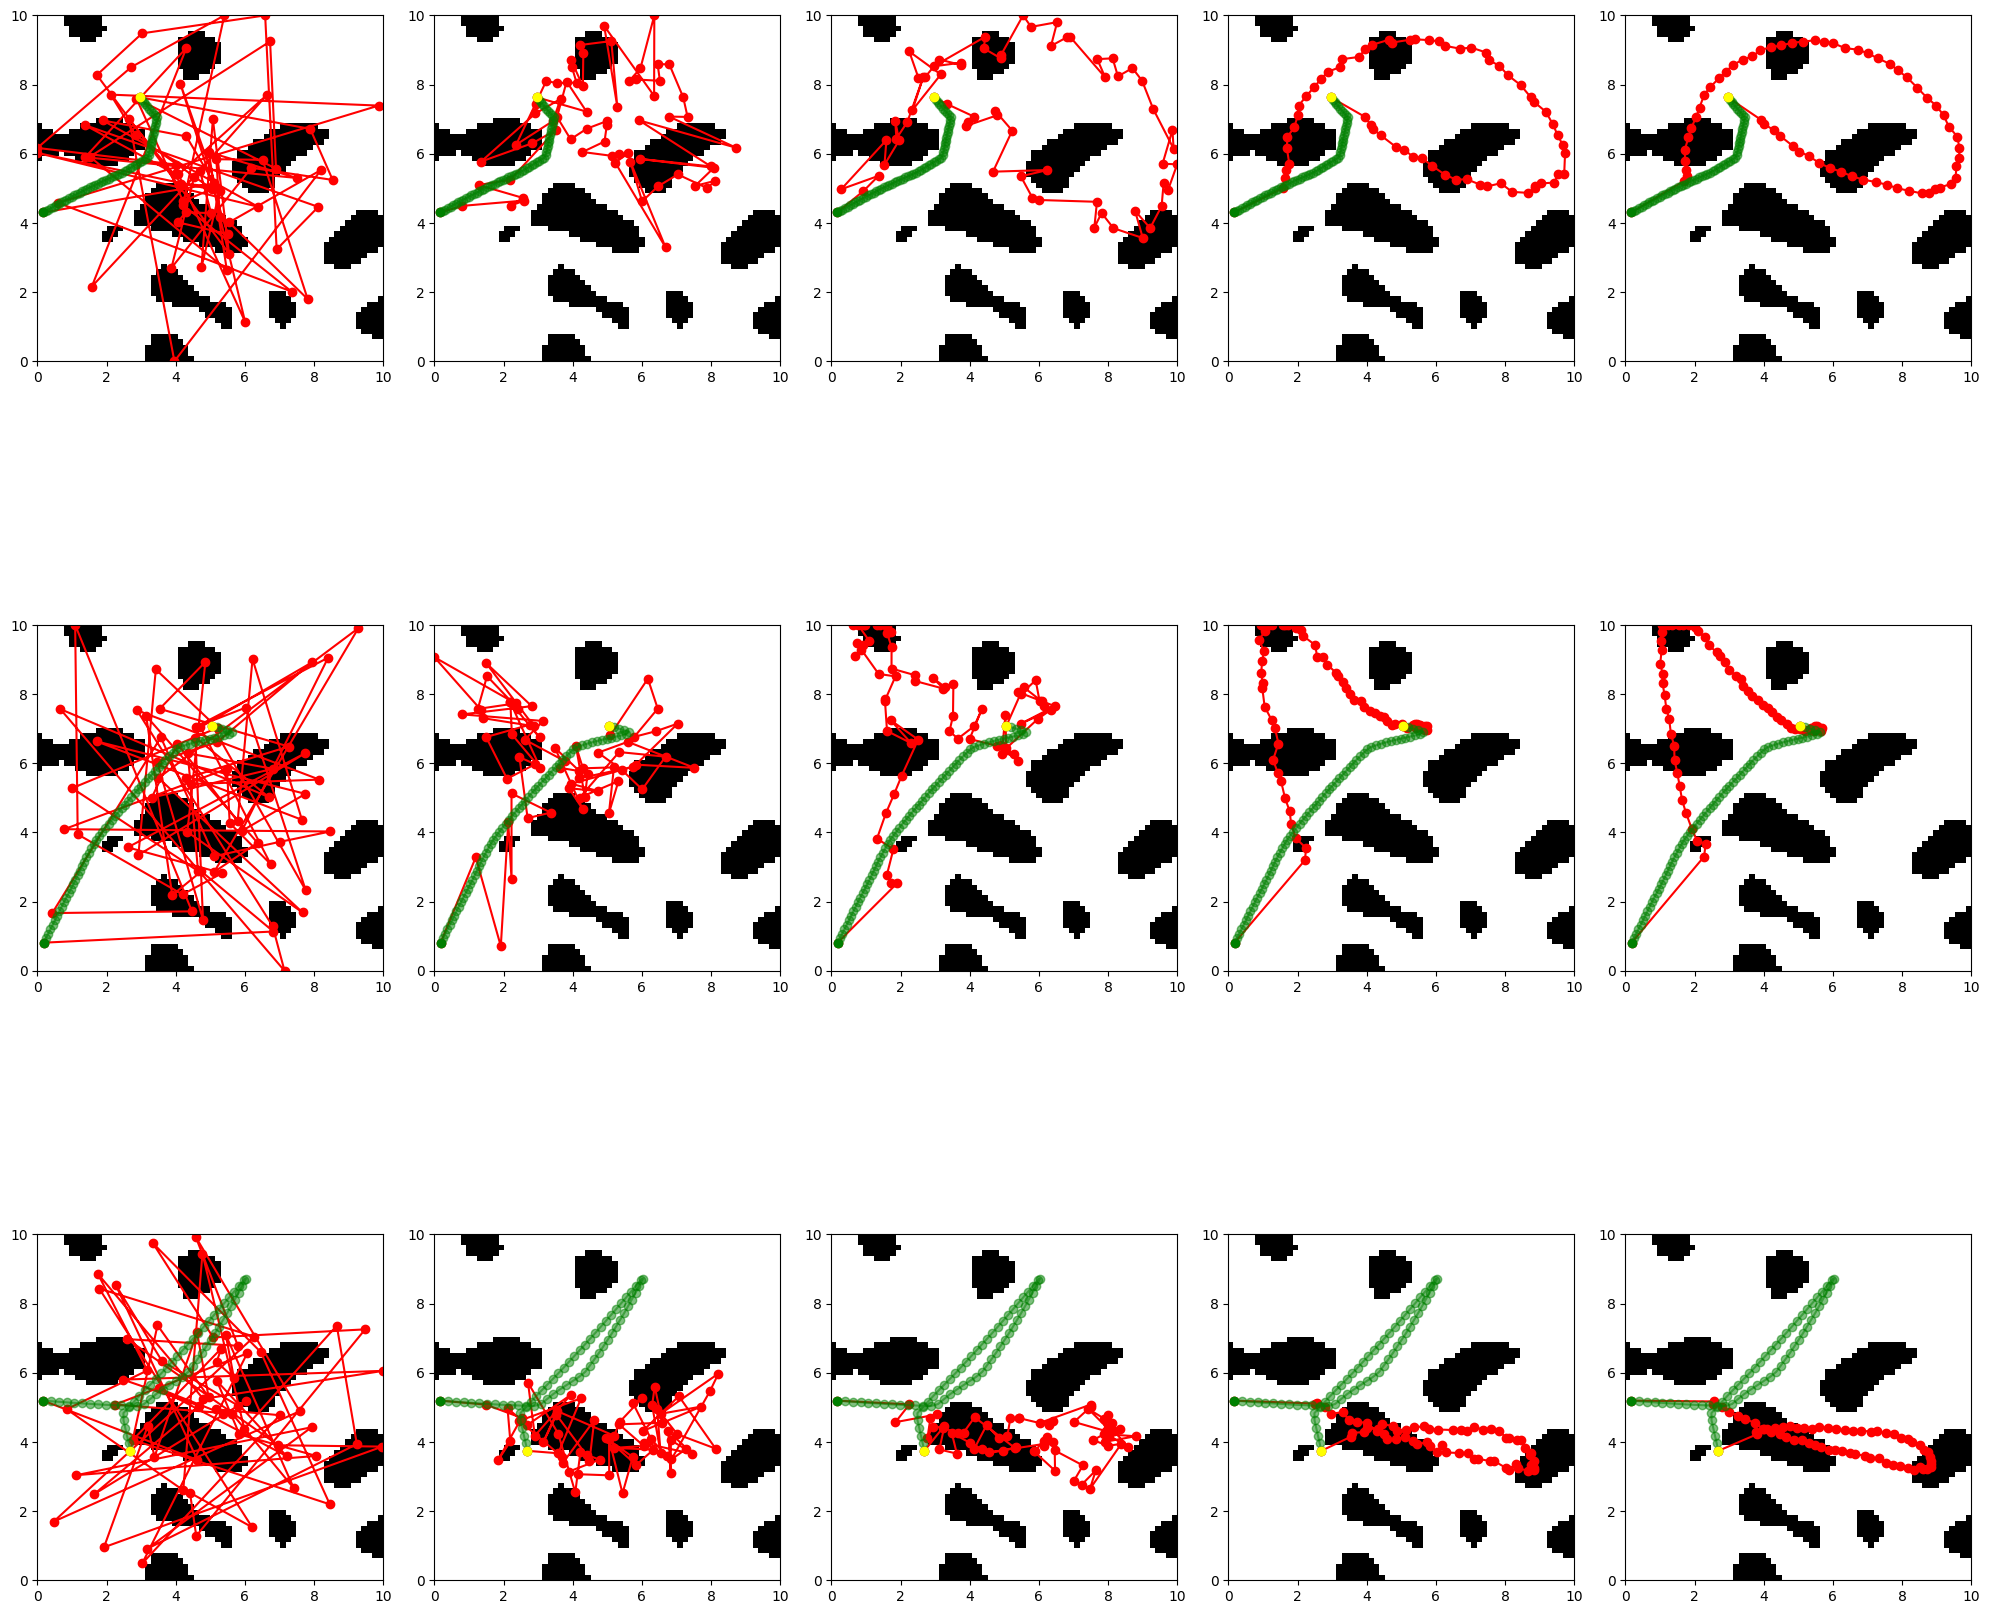

In [332]:
plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer'], true_paths=true_paths, max_plots=n);

(array([0.00388116, 0.00258744, 0.0129372 , 0.01164348, 0.03622416,
        0.09056039, 0.17723962, 0.24192562, 0.37259132, 0.54077491,
        0.76717588, 0.9573527 , 1.16176044, 1.15011696, 1.25102711,
        1.35193726, 1.1527044 , 1.06473145, 0.83962419, 0.58734882,
        0.45021451, 0.29238069, 0.1953517 , 0.10220387, 0.05692367,
        0.032343  , 0.0194058 , 0.00517488, 0.00517488, 0.00388116]),
 array([-1.13699531, -1.05969882, -0.98240234, -0.90510585, -0.82780937,
        -0.75051288, -0.67321639, -0.59591991, -0.51862342, -0.44132694,
        -0.36403045, -0.28673396, -0.20943748, -0.13214099, -0.0548445 ,
         0.02245198,  0.09974847,  0.17704495,  0.25434144,  0.33163793,
         0.40893441,  0.4862309 ,  0.56352739,  0.64082387,  0.71812036,
         0.79541684,  0.87271333,  0.95000982,  1.0273063 ,  1.10460279,
         1.18189928]),
 <BarContainer object of 30 artists>)

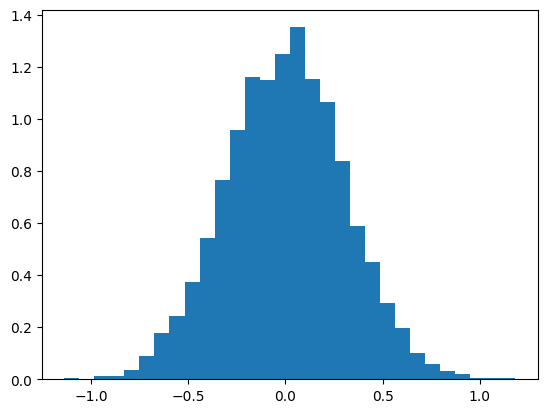

In [333]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

mu = 0
sigma = 0.3
n = 10000
values = np.random.randn(n) * sigma + mu
# values = np.clip(values, 0, 1)
# plot them
plt.hist(values, bins=30, density=True)

# Visualisations

## Dataset diversity

In [343]:
CONFIG['single_world_dataset'] = True
CONFIG['n_paths_per_world'] = 10000
if CONFIG['single_world_dataset']:
    file = os.getenv('ONE_WORLD_DATASET_PATH')
else:
    file = os.getenv('FULL_DATASET_PATH')
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'], single_world_dataset=CONFIG['single_world_dataset'], entire_dataset=CONFIG['entire_dataset'], fraction_of_data=CONFIG['fraction_of_data'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')

data shape: torch.Size([10000, 64, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:1, samples: 10000
 sample shape torch.Size([64, 2]) with 10000 samples


In [344]:
# Plot a plot with all paths that start around 5, 5 and end around 10, 10
# get batch of 500 samples
n = 999
batch = next(iter(torch.utils.data.DataLoader(dataset, batch_size=n, shuffle=True)))
batch['path'].shape

torch.Size([999, 64, 2])

In [345]:
paths = batch['path'].to(device)
world_imgs = batch['world_img']
cond = batch['world_img']
cond = cond.to(device)

In [346]:
# remove all paths that do not start around 5, 5 with 2 difference and end around 10, 10 with 2 difference
start = -0.9, -0.9
end =0.6, 0.8
diff = 0.8

start_indx = torch.where((paths[:,0,0] > start[0]-diff) & (paths[:,0,0] < start[0]+diff) & (paths[:,0,1] > start[1]-diff) & (paths[:,0,1] < start[1]+diff))
end_indx = torch.where((paths[:,-1,0] > end[0]-diff) & (paths[:,-1,0] < end[0]+diff) & (paths[:,-1,1] > end[1]-diff) & (paths[:,-1,1] < end[1]+diff))
print(f'Found {len(start_indx[0])} start points and {len(end_indx[0])} end points')
indx = torch.tensor(list(set(start_indx[0].tolist()) & set(end_indx[0].tolist())))
paths_in_der_nahe = paths[indx]
world_imgs = world_imgs[indx]
cond = cond[indx]
paths_in_der_nahe.shape, world_imgs.shape, cond.shape

Found 532 start points and 268 end points


(torch.Size([187, 64, 2]),
 torch.Size([187, 64, 64]),
 torch.Size([187, 64, 64]))

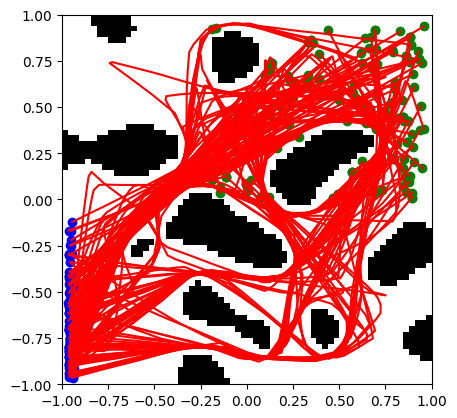

In [347]:
paths_vis = paths_in_der_nahe.cpu().detach().numpy()
# show entore path
plt.figure()
for path in paths_vis:
    plt.plot(path[:,0], path[:,1],c='r')
# show start and end point
plt.scatter(paths_vis[:,0,0], paths_vis[:,0,1], c='b')
plt.scatter(paths_vis[:,-1,0], paths_vis[:,-1,1], c='g')
# show the map
plt.imshow(world_imgs[1].T.cpu().detach().numpy(), extent=[-1, 1, -1, 1], origin='lower', cmap='binary')

In [348]:
# sample with constraints
n = 3
constraints = {
    0:torch.tensor(start).to(device),
    63: torch.tensor(end).to(device),
}
batch = next(iter(torch.utils.data.DataLoader(dataset, batch_size=n, shuffle=True)))
paths = batch['path'].to(device)
world_imgs = batch['world_img']
cond = batch['world_img']
cond = cond.to(device)


In [349]:
samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints, cond=cond,normalizer=CONFIG['normalizer'])

263it [00:20, 12.65it/s]


In [350]:
samples

tensor([[[-1.1800, -1.1800],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    nan,     nan],
         [    

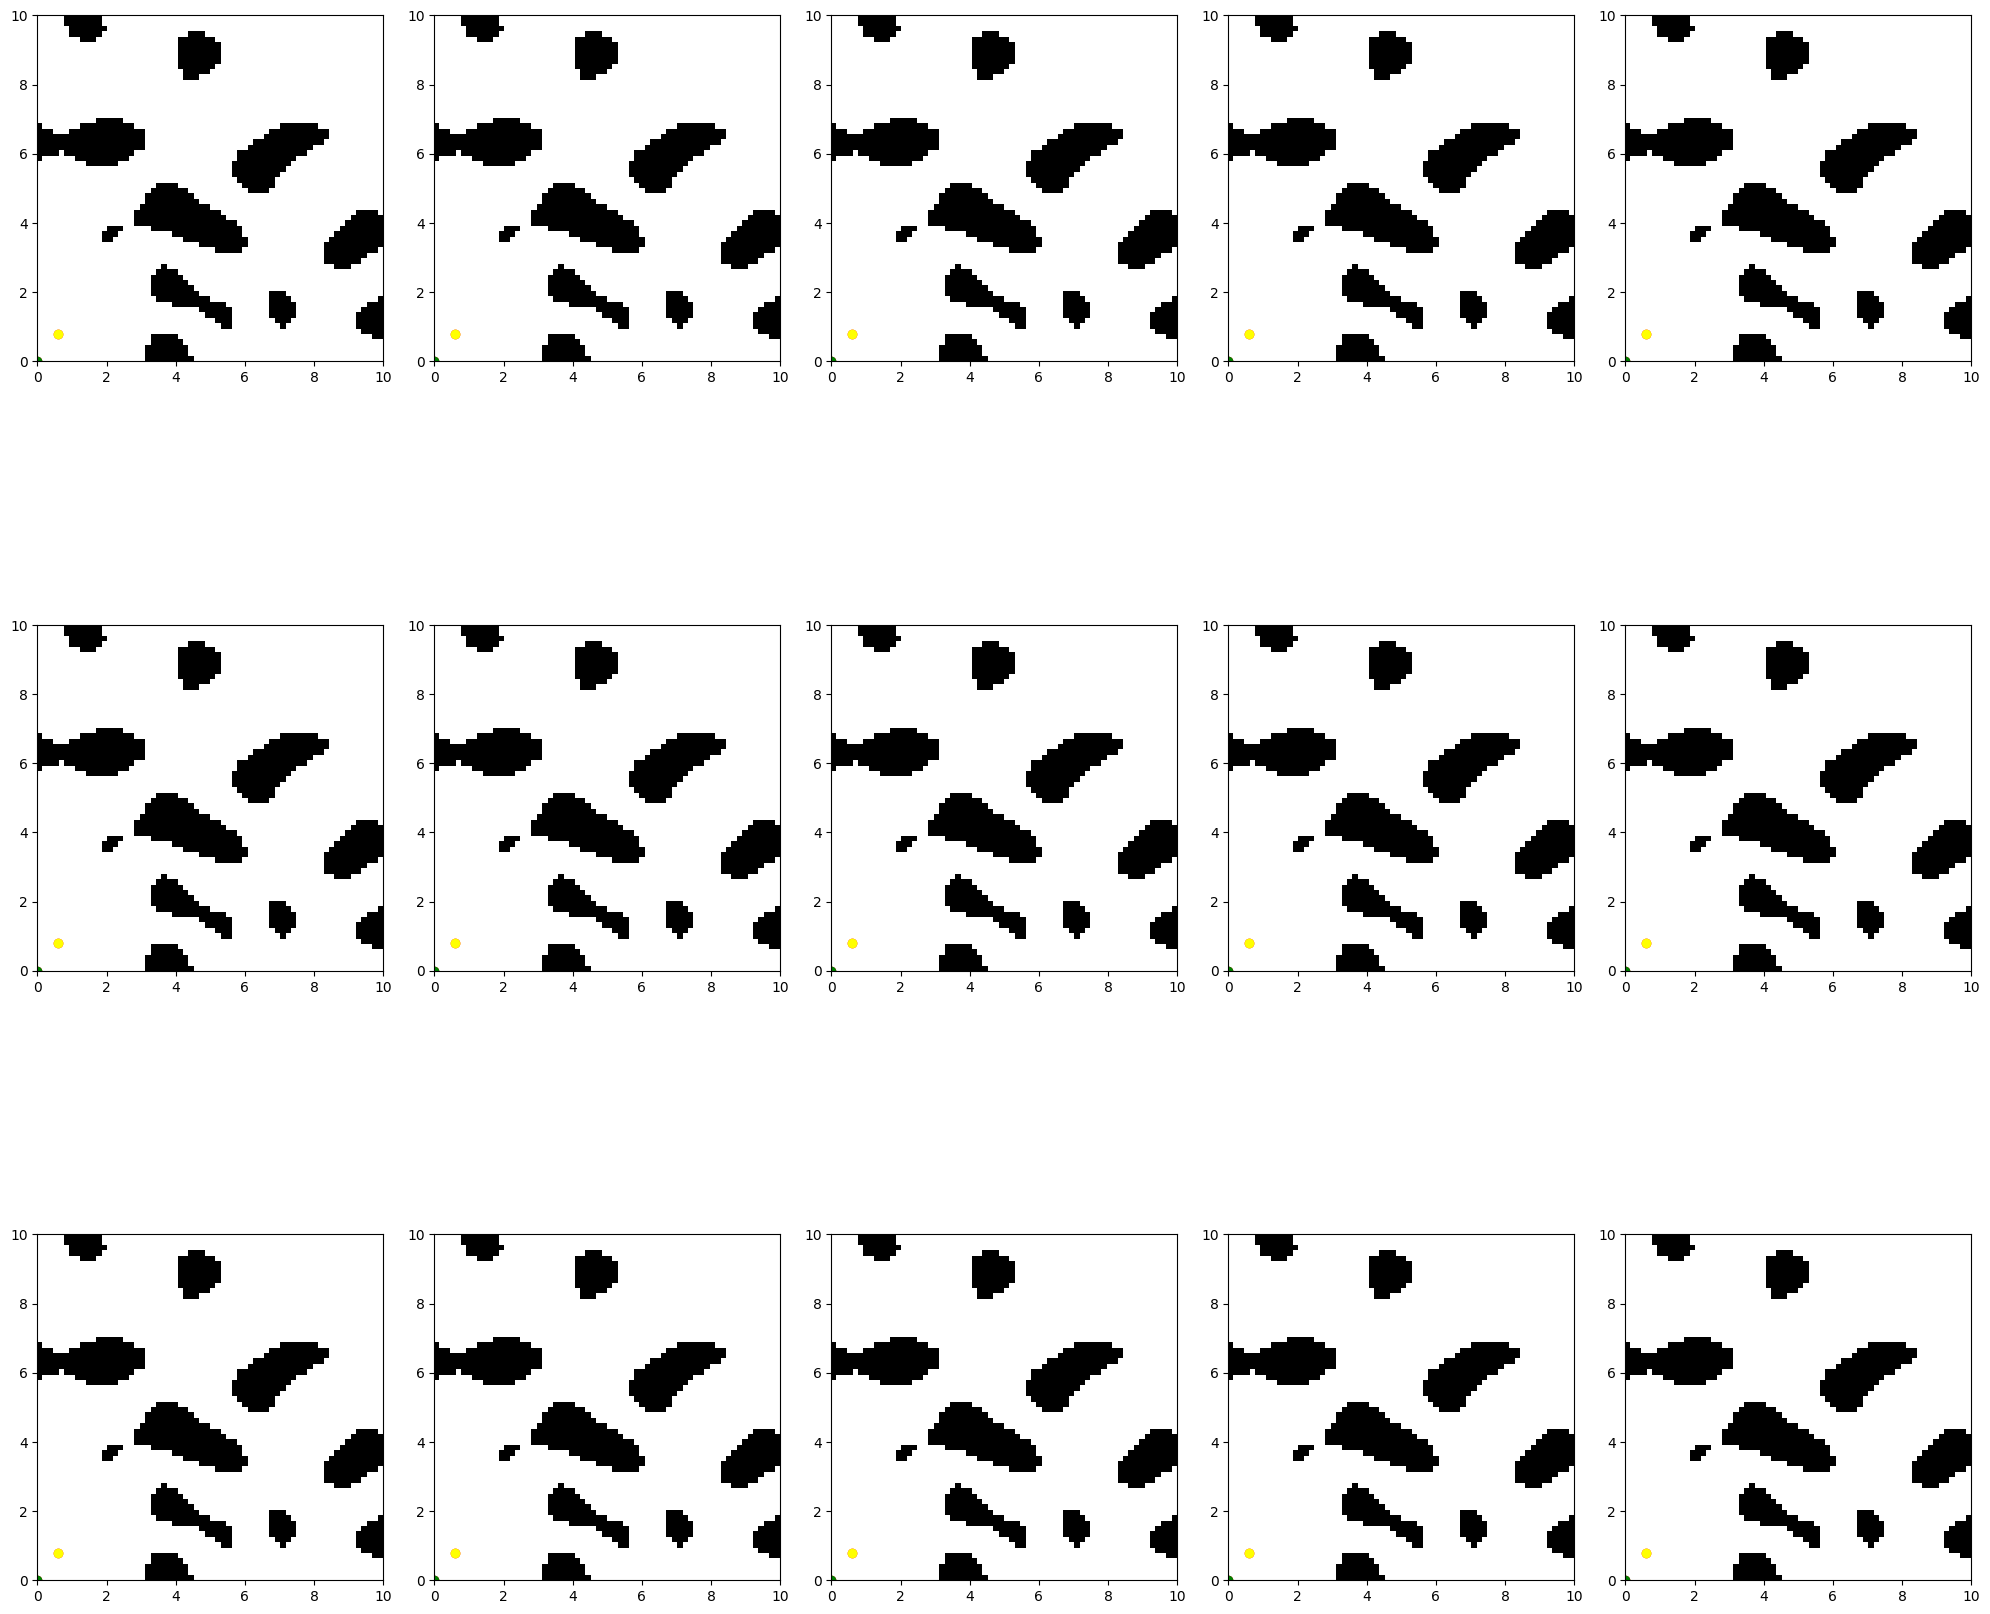

In [351]:

plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer']);